In [ ]:
# 更新履歴
## 2026/02/24 fitを個別にできるようにした
## 2026/02/08 新規作成
## 2025/12/23 機能追加
## 2025/12/22 作成

# 基本モジュール
import sys, os
from IPython.display import display, HTML, clear_output, update_display, Image
from tqdm import tqdm
import pyperclip
import pickle as pkl
import json

# データ分析用
import numpy as np
import pandas as pd
import h5py

# グラフ描画用
import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.express as px
import plotly.graph_objects as go
import PIL.Image as im

# XRDk切り開き用（不要かも）
import pyFAI

# 自作モジュール
sys.path.append(r"C:\Users\okaza\pythonenv")
from modules.Mytools.Tools import h5_tree, dict_tree, his2array, print_fileinfo, simple_progress_bar
from modules.peakfit import peakfit
import modules.Mytools.Settings

# 初期パラメーター
cachedir = os.path.join(os.getcwd(), ".cache")
os.makedirs(cachedir, exist_ok=True)
print("cache: " + os.path.abspath(cachedir))

cache: c:\Users\okaza\Documents\Documents\fpd\create_hdfdata\1Dprofile\.cache


## 目的

1次元XRDデータ(hdfファイル)をフィッティングする

## ファイル読み込み

In [473]:
hdf_1d = r"C:\Users\okaza\Documents\Documents\fpd\create_hdfdata\create_hdfdata\.cache\UODE29_0002_integrate1d.hdf"

In [474]:
# ファイルを読み込んで、plotlyで出力する
def get_data(hdf: str) -> tuple[np.ndarray, np.ndarray]:

    # データ読み込み
    ity = []
    with h5py.File(hdf, mode = "r") as f:
        tth = np.array(f["rad"][()]) # type: ignore
        for i in range(len(list(f["integrated"].keys()))): # type: ignore
            ity.append(f["integrated/frame = {}".format(i)][()]) # type: ignore
    ity = np.vstack(ity)

    # figure作成
    if True:

        # インスタント化
        fig = go.Figure()

        # 一枚目作成
        raw_anim = go.Scatter(
            x = tth,
            y = ity[0],
            mode = "lines",
            line = dict(
                color = "#000000",
                width = 1,
            )
        )
        fig.add_trace(raw_anim)

        # アニメーションフレームを作成
        frame_list = [
            go.Frame(
                data = [
                    go.Scatter(
                        y = ity[k]
                    )
                ],
                name = str(k),
            ) for k in range(ity.shape[0])
        ]
        fig.frames = frame_list

        # フレーム変更用のボタンとスライダー
        updatemenus_frame = dict(
            type='buttons',
            direction = 'left', # 横並びの場合 'left', 縦並びの場合 'down'
            showactive=False,
            active = -1,
            y=0,
            x=0,
            xanchor='left',
            yanchor='top',
            pad=dict(t=65, r=0),
            buttons=[
                dict(
                    label='▶︎',
                    method='animate',
                    args=[
                        None,
                        dict(
                            frame=dict(
                                duration=200,
                                redraw=True
                            ),
                            fromcurrent=True,
                            mode='immediate',
                            transition=dict(duration=0)
                        )
                    ]
                ),
                dict(
                    label='⏸',
                    method='animate',
                    args=[
                        [None],
                        dict(
                            frame=dict(
                                duration=0,
                                redraw=False
                            ),
                            mode='immediate',
                            transition=dict(duration=0)
                        )
                    ]
                )
            ],
            visible = True
        )
        slider = dict(
            steps=[dict(
                method='animate',
                args=[
                    [str(k)],
                    dict(
                        mode='immediate',
                        frame=dict(
                            duration=0,
                            redraw=True
                            ),
                        transition=dict(
                            duration=0
                        )
                    )
                ],
                label=str(k),
            ) for k in range(ity.shape[0])],
            ticklen = 0,
            minorticklen = 0,
            active=0,
            y=0,
            x=0, # スライダーの開始位置
            len=1, # スライダーの長さ
            xanchor='left',
            yanchor='top',
            pad=dict(
                b=10,
                t=50,
                l=100
            ),
            currentvalue=dict(
                prefix='Frame = ',
                visible=True,
                xanchor='left'
            ),
            visible = True,
        )

        fig.update_layout(
            title = dict(
                text = os.path.splitext(os.path.basename(hdf))[0],
                font = dict(
                    size = 26,
                    color = "#777777"
                ),
                x = 0.05,
                y = 0.95,
                xanchor = "left",
                yanchor = "top",
            ),
            xaxis = {
                'title': "2theta [deg.]",
                "linecolor": "#000000",
                "linewidth": 1,
                'ticks': "inside",
                "tickcolor": "#000000",
                "tickwidth": 1,
                "ticklen": 5,
                'mirror': True,
            },
            yaxis = {
                'title': "Frame",
                "linecolor": "#000000",
                "linewidth": 1,
                'ticks': "inside",
                "tickcolor": "#000000",
                "tickwidth": 1,
                "ticklen": 5,
                'mirror': True,
            },
            plot_bgcolor = '#ffffff',
            updatemenus = [
                updatemenus_frame,
            ],
            sliders = [slider],
            showlegend = False,
            legend = dict(
                bordercolor = "#000000",
                orientation = "h",
                yanchor = "bottom",
                y = 1,
                bgcolor = "rgba(255,255,255,0)",
                xanchor = "center",
                x = 0.5
            ),
            width = 800,
            height = 600,
        )

        fig.show()

    return (tth, ity)
tth, ity = get_data(hdf_1d)
print(tth.shape, ity.shape)
del get_data

(5400,) (42, 5400)


## フィッティング

Input:
	init_center: 20.9625
	init_fwhm: 0.03
	fit_len: {'left': 0.6, 'right': 0.6}
	threshold: 1e-20
	maxfit: 40
	hdf: D:\DATA\SPring-8-2025-Dec\Analysis\UODE36_run1\integrated_1d\UODE36_0020_integrate1d.hdf
	func: asympsdVoigt
	fit: True
	frame: 0
	auto: True
Progress: [■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■] 100% (219/219) 
Save: c:\Users\okaza\Documents\Documents\fpd\create_hdfdata\1Dprofile\.cache\display_fitres.png


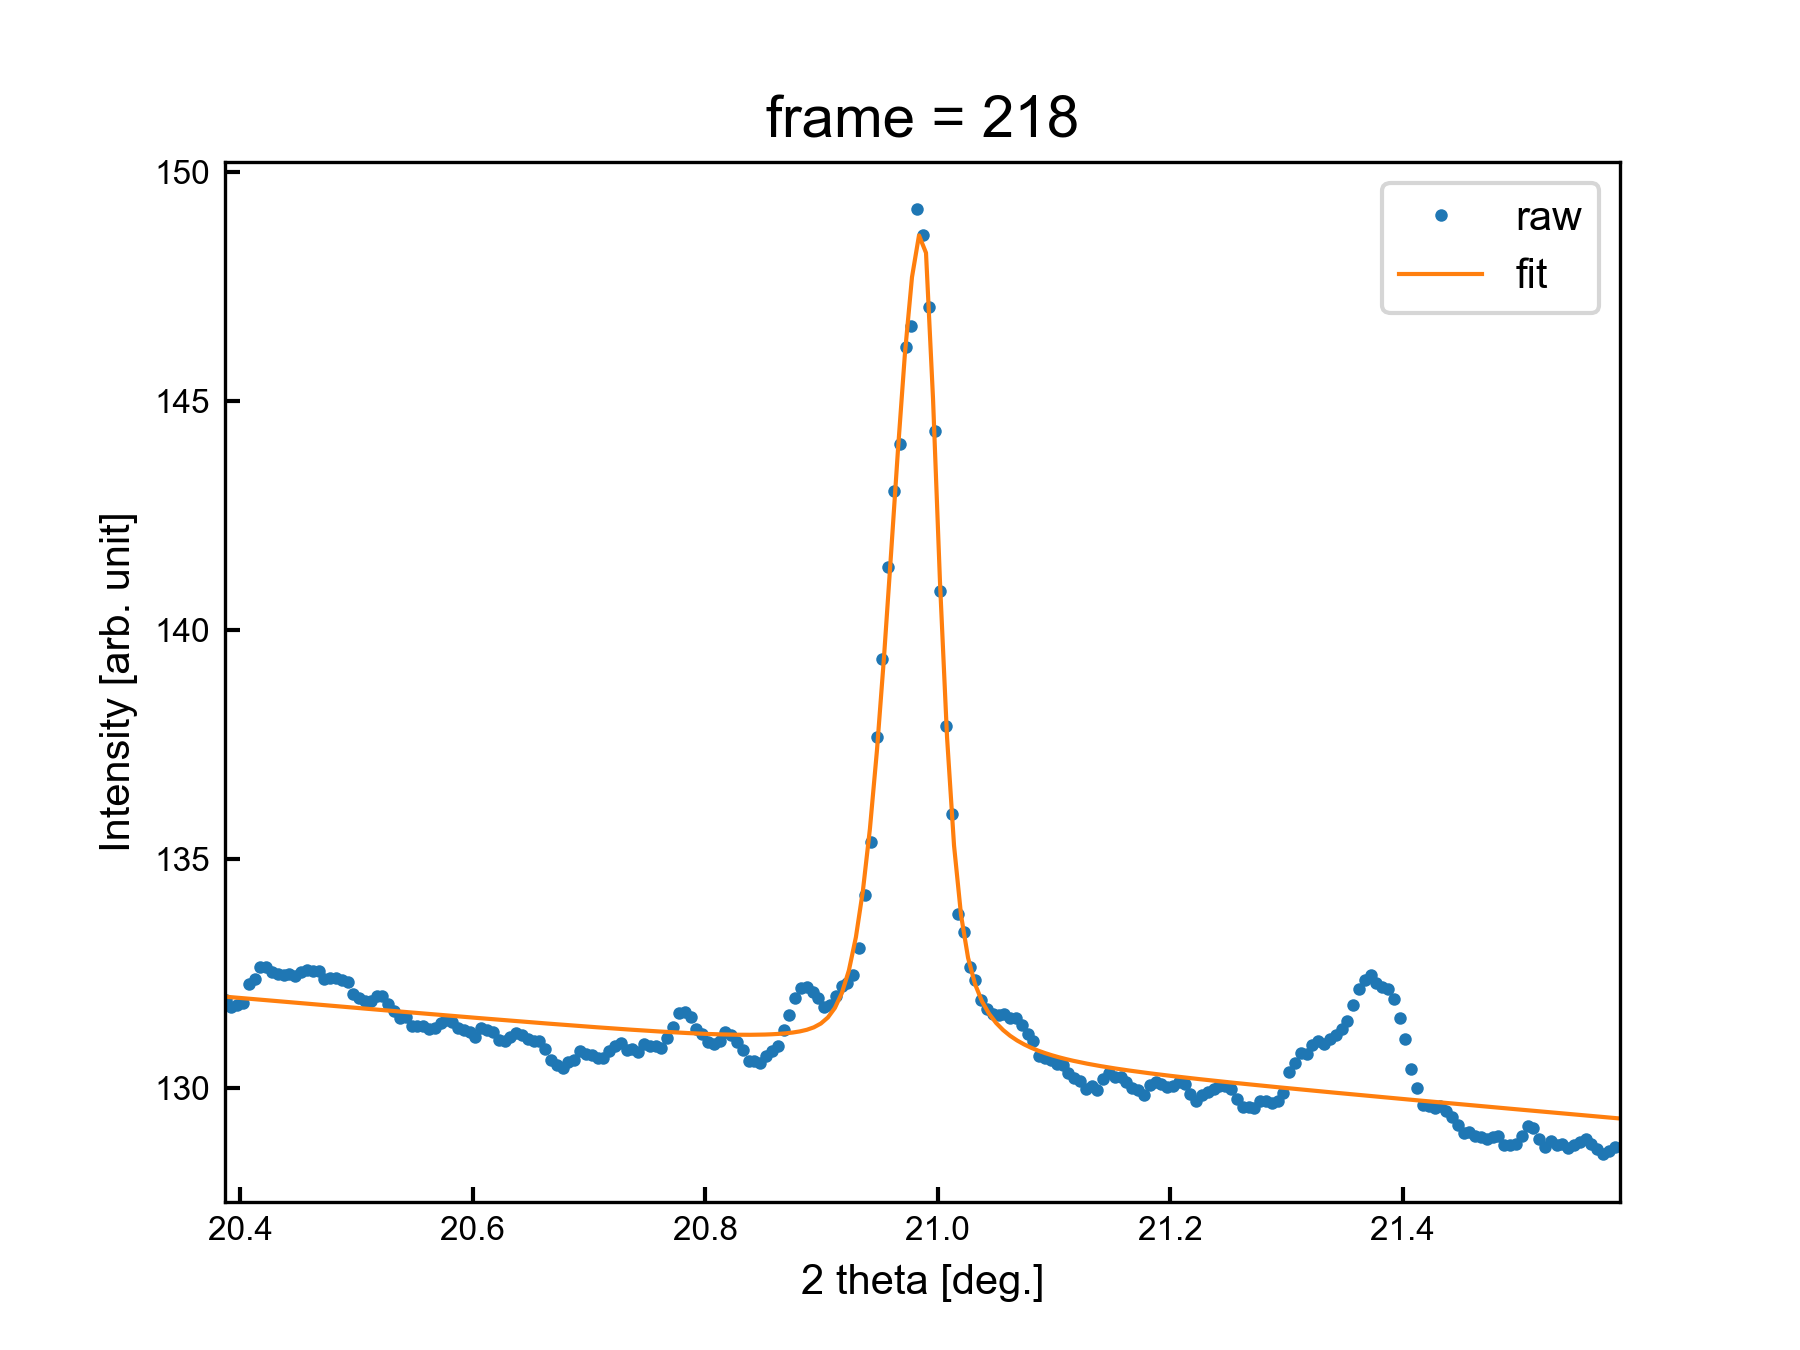

<class 'dict'>  (size = 0.62 MB)
├── fitres
│   ├── frame = 0
│   │   ├── res
│   │   │   ├── params
│   │   │   │   ├── b0 <class 'numpy.float64'>
│   │   │   │   ├── b1 <class 'numpy.float64'>
│   │   │   │   ├── center <class 'numpy.float64'>
│   │   │   │   ├── height <class 'numpy.float64'>
│   │   │   │   ├── left
│   │   │   │   │   ├── fwhm <class 'numpy.float64'>
│   │   │   │   │   └── factor <class 'numpy.float64'>
│   │   │   │   └── right
│   │   │   │       ├── fwhm <class 'numpy.float64'>
│   │   │   │       └── factor <class 'numpy.float64'>
│   │   │   ├── err
│   │   │   │   ├── b0 <class 'numpy.float64'>
│   │   │   │   ├── b1 <class 'numpy.float64'>
│   │   │   │   ├── center <class 'numpy.float64'>
│   │   │   │   ├── height <class 'numpy.float64'>
│   │   │   │   ├── left
│   │   │   │   │   ├── fwhm <class 'numpy.float64'>
│   │   │   │   │   └── factor <class 'numpy.float64'>
│   │   │   │   └── right
│   │   │   │       ├── fwhm <class 'numpy.float64'>
│   │   

In [472]:
# 初期フレーム
frame = 0

# 初期値（ピーク位置）
init_center = 20.9625

# 初期値（半値幅）
init_fwhm = 0.03

# フィッティング範囲
fit_len = {
    "left": 0.6,
    "right": 0.6,
}

# フィッティング関数
# func = "psdVoigt"
func = "asympsdVoigt"

# フィッティング
fit = True
# fit = False

# 連続フィッティング
auto = True
# auto = False

def fit_step(
        tth: np.ndarray,
        ity: np.ndarray,
        init_center: float,
        init_fwhm: float,
        fit_len: dict,
        threshold: float,
        maxfit: int,
        hdf: str,
        func: str,
        fit: bool,
        frame: int,
        auto: bool,
    ) -> dict:

    # 引数の確認
    print("="*70)
    print("Input:")
    print("\tinit_center: {}".format(init_center))
    print("\tinit_fwhm: {}".format(init_fwhm))
    print("\tfit_len: {}".format(fit_len))
    print("\tthreshold: {}".format(threshold))
    print("\tmaxfit: {}".format(maxfit))
    print("\thdf: {}".format(hdf))
    print("\tfunc: {}".format(func))
    print("\tfit: {}".format(fit))
    print("\tframe: {}".format(frame))
    print("\tauto: {}".format(auto))
    print("="*70)

    # 出力用変数
    output = dict(
        frame = frame
    )

    # フィッティング用変数
    center = init_center
    fwhm = init_fwhm
    fit_count = 0
    res_dict = dict(fitres = dict())
    if not (func in ["psdVoigt", "asympsdVoigt"]):
        raise KeyError("func is either 'psdVoigt' or 'asympsdVoigt'")
    pf = peakfit()
    
    # 読み込み
    jsonfilename = os.path.join(cachedir, "fitres.json")
    if os.path.exists(jsonfilename):
        with open(jsonfilename, mode = "r") as f:
            res_dict = json.load(f)
        if res_dict["func"] != func:
            raise KeyError("The fitting function has been changed!")
    
    # 表示用の関数を定義
    def display_fitres(fit_range: tuple,
                       tth: np.ndarray,
                       d: np.ndarray,
                       func,
                       params: dict,
                       title: str,
                       ) -> str:
        
        # 演算
        xs = np.linspace(*fit_range, 200) # type: ignore
        ys = func(x = xs, params = params) # type: ignore

        # figure作成
        fig, ax = plt.subplots()
        fig.set_size_inches(6,4.5)
        ax.plot(
            tth,
            d,
            lw = 0,
            marker = "o",
            ms = 3,
            c = "tab:blue",
            mew = 0,
            label = "raw",
        )
        ax.plot(
            xs,
            ys,
            c = "tab:orange",
            lw = 1,
            label = "fit",
        )
        ax.set_title(title, fontsize = 14)
        ax.legend(fontsize = 10)
        ax.set_xlim(fit_range)
        ax.set_xlabel("2 theta [deg.]", fontsize = 10)
        ax.set_ylabel("Intensity [arb. unit]", fontsize = 10)
        pngfile = os.path.join(cachedir, "display_fitres.png")
        plt.savefig(pngfile, dpi = 300)
        plt.close()
        return pngfile

    n_frame = ity.shape[0]
    
    while True:

        # データ取得
        d = ity[frame]
        fit_range = tuple(np.array([fit_len[side] for side in ["left", "right"]])*np.array([-1,1]) + center)
        fit_mask = (tth > fit_range[0]) * (tth < fit_range[1])

        if not fit_count:
            # 初期値を計算する
            ip = pf.calc_initparams(
                x = tth[fit_mask],
                y = d[fit_mask],
                func = func
            )
            ip["center"] = center
            if func == "asympsdVoigt":
                for k in ["left", "right"]:
                    ip[k]["fwhm"] = fwhm
            else:
                ip["fwhm"] = fwhm

        if not fit:
            pngfilename = display_fitres(
                fit_range,
                tth[fit_mask],
                d[fit_mask],
                func = lambda x, params: (pf.psdVoigt(x,params) if (func == "psdVoigt") else pf.asympsdVoigt(x,params)) + pf.background(x,params),
                params = ip,
                title = "frame = {}".format(frame),
            )
            print("Save: " + pngfilename)
            display(Image(filename = pngfilename, width = 600))
            break
        else:
            # フィッティングする
            res = pf.fit(
                x = tth[fit_mask],
                y = d[fit_mask],
                initparams = ip,
                func = func,
            )
            if type(res) == RuntimeError:
                print("Raise fitting error!")
                pngfilename = display_fitres(
                    fit_range,
                    tth[fit_mask],
                    d[fit_mask],
                    func = lambda x, params: (pf.psdVoigt(x,params) if (func == "psdVoigt") else pf.asympsdVoigt(x,params)) + pf.background(x,params),
                    params = ip,
                    title = "frame = {}".format(frame)
                )
                print("Save: " + pngfilename)
                display(Image(filename = pngfilename, width = 600))
                break
            
            # 決定係数の計算
            rss = np.sum(np.square(d[fit_mask] - res["func"](x = tth[fit_mask], params = res["params"])))
            tss = np.sum(np.square(d[fit_mask] - np.mean(d[fit_mask])))
            r2 = 1 - rss/tss
            
            if not fit_count:
                # 変数を引き継ぐ
                fit_count += 1
                current_r2 = r2        
                ip = res["params"]
                center = ip["center"]
                continue
            else:
                # 収束判定 (r2に変化がなくなったら終了)
                delta_r2 = (r2 - current_r2)/r2
                if (delta_r2 < threshold) or (fit_count > maxfit):
                    res_dict["fitres"]["frame = {}".format(frame)] = dict(
                        res = res,
                        range = fit_range,
                    )
                    fit_count = 0
                    center = res["params"]["center"]
                    if func == "psdVoigt":
                        fwhm = res["params"]["fwhm"]
                    else:
                        fwhm = np.mean([res["params"][k]["fwhm"] for k in ["left", "right"]])
                    if auto and (frame < n_frame-1):
                        frame += 1
                        simple_progress_bar(current = frame+1, total = n_frame)
                        continue
                    else:
                        pngfilename = display_fitres(
                            fit_range,
                            tth[fit_mask],
                            d[fit_mask],
                            func = lambda x, params: (pf.psdVoigt(x,params) if (func == "psdVoigt") else pf.asympsdVoigt(x,params)) + pf.background(x,params),
                            params = res["params"],
                            title = "frame = {}".format(frame)
                        )
                        print("Save: " + pngfilename)
                        display(Image(filename = pngfilename, width = 600))
                        break
                else:
                    fit_count += 1
                    current_r2 = r2
                    ip = res["params"]
                    center = ip["center"]
                    continue

    for k in res_dict["fitres"].keys():
        if "func" in res_dict["fitres"][k]["res"].keys():
            del res_dict["fitres"][k]["res"]["func"],res_dict["fitres"][k]["res"]["pcov"],res_dict["fitres"][k]["res"]["popt"]
    res_dict["func"] = func # type:ignore
    res_dict["hdf"] = hdf # type:ignore
    dict_tree(res_dict)
    print()
    jsonfilename = os.path.join(cachedir, "fitres.json")
    with open(jsonfilename, mode = "w") as f:
        json.dump(res_dict, f, indent = 4)
    print("Save: " + os.path.abspath(jsonfilename))

    return output
res = fit_step(tth = tth,
               ity = ity,
               init_center = init_center,
               init_fwhm = init_fwhm,
               fit_len = fit_len,
               threshold = 1e-20,
               maxfit = 40,
               hdf = hdf_1d,
               func = func,
               fit = fit,
               frame = frame,
               auto = auto,
               )
frame = res["frame"]
del fit_step

In [ ]:
# (fitting パラメータ for Fe3C)
# ピーク位置
init_center = 15.0075

# ピーク半値全幅 [deg.]
init_fwhm = 0.1

# フィッティングする範囲 [deg.]
fit_len = 0.53

# フィッティング関数
# func = "psdVoigt"
func = "asympsdVoigt"

In [ ]:
# fittingを行う
def fit(tth: np.ndarray,
        ity: np.ndarray,
        init_center: float,
        init_fwhm: float,
        fit_len: float,
        threshold: float,
        maxfit: int,
        hdf: str,
        func: str
        ) -> str:

    # フィッティング用変数
    center = init_center
    fwhm = init_fwhm
    fit_count = 0
    res_dict = dict(fitres = dict())
    if not (func in ["psdVoigt", "asympsdVoigt"]):
        raise KeyError("func is either 'psdVoigt' or 'asympsdVoigt'")
    
    # 表示用の関数を定義
    def display_fitres(fit_range: tuple,
                       tth: np.ndarray,
                       d: np.ndarray,
                       func,
                       params: dict,
                       ) -> None:
        
        # 演算
        xs = np.linspace(*fit_range, 100) # type: ignore
        ys = func(x = xs, params = params) # type: ignore

        # figure作成
        fig, ax = plt.subplots()
        fig.set_size_inches(6,4.5)
        ax.plot(
            tth[fit_mask],
            d[fit_mask],
            lw = 0,
            marker = "o",
            ms = 3,
            c = "tab:blue",
            mew = 0,
            label = "raw",
        )
        ax.plot(
            xs,
            ys,
            c = "tab:orange",
            lw = 1,
            label = "fit",
        )
        ax.legend(fontsize = 10)
        ax.set_xlim(fit_range)
        ax.set_xlabel("2 theta [deg.]", fontsize = 10)
        ax.set_ylabel("Intensity [arb. unit]", fontsize = 10)
        plt.show()
        plt.close()
        return

    # インスタント化
    pf = peakfit()

    for i in tqdm(range(ity.shape[0])):
        while True:

            # データ取得
            d = ity[i]
            fit_range = tuple(np.array([-1/2,1/2]) * fit_len + center)
            fit_mask = (tth > fit_range[0]) * (tth < fit_range[1])

            # 初期値を計算する
            if not fit_count:
                ip = pf.calc_initparams(
                    x = tth[fit_mask],
                    y = d[fit_mask],
                    func = func
                )
                # ip["center"] = tth[fit_mask][np.argmax(d[fit_mask])]
                ip["center"] = center
                if func == "asympsdVoigt":
                    for k in ["left", "right"]:
                        ip[k]["fwhm"] = fwhm
                else:
                    ip["fwhm"] = fwhm
                # display_fitres(
                #     fit_range = fit_range,
                #     tth = tth,
                #     d = d,
                #     func = lambda x, params: (pf.psdVoigt(x,params) if (func == "psdVoigt") else pf.asympsdVoigt(x,params)) + pf.background(x,params),
                #     params = ip,
                # )
                # return ""

            # フィッティングする
            res = pf.fit(
                x = tth[fit_mask],
                y = d[fit_mask],
                initparams = ip,
                func = func,
            )
            
            # 決定係数の計算
            rss = np.sum(np.square(d[fit_mask] - res["func"](x = tth[fit_mask], params = res["params"])))
            tss = np.sum(np.square(d[fit_mask] - np.mean(d[fit_mask])))
            r2 = 1 - rss/tss
            
            if not fit_count:
                # 変数を引き継ぐ
                fit_count += 1
                current_r2 = r2        
                ip = res["params"]
                center = ip["center"]
                continue
            else:
                # 収束判定 (r2に変化がなくなったら終了)
                delta_r2 = (r2 - current_r2)/r2
                if (delta_r2 < threshold) or (fit_count > maxfit):                        
                    res_dict["fitres"]["frame = {}".format(i)] = dict(
                        res = res,
                        range = fit_range,
                    )
                    fit_count = 0
                    center = res["params"]["center"]
                    if func == "psdVoigt":
                        fwhm = res["params"]["fwhm"]
                    else:
                        fwhm = np.mean([res["params"][k]["fwhm"] for k in ["left", "right"]])
                    break                
                else:
                    fit_count += 1
                    current_r2 = r2
                    ip = res["params"]
                    center = ip["center"]
                    continue

        # display_fitres(
        #     fit_range = fit_range,
        #     tth = tth,
        #     d = d,
        #     func = res["func"],
        #     params = res["params"],
        # )
        # return ""

    for k in res_dict["fitres"].keys():
        del res_dict["fitres"][k]["res"]["func"],res_dict["fitres"][k]["res"]["pcov"],res_dict["fitres"][k]["res"]["popt"]
    res_dict["func"] = func # type:ignore
    res_dict["hdf"] = hdf # type:ignore
    jsonfilename = os.path.join(cachedir, "fitres.json")
    with open(jsonfilename, mode = "w") as f:
        json.dump(res_dict, f, indent = 4)
    print("Save: " + os.path.abspath(jsonfilename))

    return jsonfilename
fit(tth = tth,
    ity = ity,
    init_center = init_center,
    init_fwhm = init_fwhm,
    fit_len = fit_len,
    threshold = 1e-20,
    maxfit = 40,
    hdf = hdf_1d,
    func = func
    )
del fit